In [1]:
import pymc as pm
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pytensor as pt

df = pd.read_csv('full_data_bhm1.csv', keep_default_na=False, na_values=[''])

years = [i for i in range(2020, 2026)]
states = df['state'].unique()
regions = df['region'].unique()

state_data = []
region_data = []
for year in years:
    for state in states:
        state_df_temp = df[df['state'] == state]
        total = state_df_temp[f'totalByState_{year}'].sum()
        closed = state_df_temp[f'closedByState_{year}'].sum()
        if total > 0:
            state_data.append({'state': state, 'year': year, 'total': total, 'closed': closed})
    for region in regions:
        region_df_temp = df[df['region'] == region]
        total = region_df_temp[f'totalByRegion_{year}'].sum()
        closed = region_df_temp[f'closedByRegion_{year}'].sum()
        if total > 0:
            region_data.append({'region': region, 'year': year, 'total': total, 'closed': closed})

state_df = pd.DataFrame(state_data)
region_df = pd.DataFrame(region_data)

df

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,totalByRegion_2023,closedByRegion_2023,totalByState_2024,closedByState_2024,totalByRegion_2024,closedByRegion_2024,totalByState_2025,closedByState_2025,totalByRegion_2025,closedByRegion_2025
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,2055,1,69,0,2055,4,69,0,2055,2
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,1163,4,413,3,1163,8,413,0,1163,0
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,1323,6,102,1,1323,9,102,0,1323,4
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,1163,4,144,1,1163,8,144,0,1163,0
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,1163,4,144,0,1163,8,144,0,1163,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Eastern Nazarene College,1900,Massachusetts,MA,Suburb,Large,Private,Nonprofit,4-year,True,...,1163,4,144,1,1163,8,144,0,1163,0
61,Cox College,1907,Missouri,MO,City,Midsize,Private,Nonprofit,4-year,True,...,1323,6,137,0,1323,9,137,2,1323,4
62,University of Wisconsin–Platteville Richland,1967,Wisconsin,WI,Town,Distant,Public,Nonprofit,4-year,True,...,1323,6,88,4,1323,9,88,1,1323,4
63,Maryland University of Integrative Health,1974,Maryland,MD,Suburb,Large,Private,Nonprofit,graduate school,False,...,2055,1,77,0,2055,4,77,1,2055,2


In [2]:
with pt.config.change_flags(exception_verbosity='high'):
    with pm.Model() as model:
        mu_global = pm.Normal('mu_global', mu=0, sigma=10)
        sigma_region = pm.HalfNormal('sigma_region', sigma=5)
        region_effects = pm.Normal('region_effects', mu=0, sigma=sigma_region, shape=len(regions))
        
        region_idx_map = {region: i for i, region in enumerate(regions)}
        state_to_region = dict(zip(df['state'], df['region']))
        state_region_idx = [region_idx_map[state_to_region[state_df.loc[i, 'state']]] for i in range(len(state_df))]
        
        sigma_state = pm.HalfNormal('sigma_state', sigma=5)
        state_effects = pm.Normal('state_effects', mu=region_effects[state_region_idx], sigma=sigma_state, shape=len(state_df))
        
        logit_p = mu_global + state_effects
        p = pm.Deterministic('p', pm.math.sigmoid(logit_p))
        y = pm.Binomial('y', n=state_df['total'], p=p, observed=state_df['closed'])
        
        trace = pm.sample(return_inferencedata=True, random_seed=42, progressbar=True)

az.to_netcdf(trace, 'good_bhm_traces/states_1k_1k_4.nc')

print(f"r_hat > 1.01: {(az.rhat(trace) > 1.01).sum()}")
print(f"ess < 100: {(az.ess(trace) < 100).sum()}")
print(f"ess < 1000: {(az.ess(trace) < 1000).sum()}")
az.summary(trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, sigma_region, region_effects, sigma_state, state_effects]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 83 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


r_hat > 1.01: <xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       int64 8B 1
    region_effects  int64 8B 4
    state_effects   int64 8B 59
    sigma_region    int64 8B 1
    sigma_state     int64 8B 1
    p               int64 8B 0
ess < 100: <xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       int64 8B 1
    region_effects  int64 8B 0
    state_effects   int64 8B 1
    sigma_region    int64 8B 0
    sigma_state     int64 8B 0
    p               int64 8B 0
ess < 1000: <xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       int64 8B 1
    region_effects  int64 8B 4
    state_effects   int64 8B 142
    sigma_region    int64 8B 1
    sigma_state     int64 8B 1
    p               int64 8B 0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,-7.163,0.566,-8.249,-6.079,0.072,0.085,94.0,51.0,1.05
region_effects[0],-0.181,0.555,-1.529,0.696,0.056,0.074,154.0,58.0,1.03
region_effects[1],0.006,0.548,-1.162,1.039,0.060,0.084,131.0,60.0,1.04
region_effects[2],0.275,0.572,-0.743,1.251,0.068,0.107,148.0,52.0,1.03
region_effects[3],-0.016,0.576,-1.223,0.973,0.060,0.084,158.0,65.0,1.03
...,...,...,...,...,...,...,...,...,...
p[163],0.001,0.002,0.000,0.004,0.000,0.000,2961.0,2347.0,1.00
p[164],0.002,0.006,0.000,0.009,0.000,0.000,2809.0,2507.0,1.00
p[165],0.001,0.002,0.000,0.005,0.000,0.000,3085.0,2085.0,1.00
p[166],0.007,0.008,0.000,0.020,0.000,0.000,4266.0,2690.0,1.00


In [3]:
with pt.config.change_flags(exception_verbosity='high'):
    with pm.Model() as model:
        mu_global = pm.Normal('mu_global', mu=0, sigma=10)
        sigma_region = pm.HalfNormal('sigma_region', sigma=5)
        region_effects = pm.Normal('region_effects', mu=0, sigma=sigma_region, shape=len(regions))
        
        region_idx_map = {region: i for i, region in enumerate(regions)}
        state_to_region = dict(zip(df['state'], df['region']))
        state_region_idx = [region_idx_map[state_to_region[state_df.loc[i, 'state']]] for i in range(len(state_df))]
        
        sigma_state = pm.HalfNormal('sigma_state', sigma=5)
        state_effects = pm.Normal('state_effects', mu=region_effects[state_region_idx], sigma=sigma_state, shape=len(state_df))
        
        logit_p = mu_global + state_effects
        p = pm.Deterministic('p', pm.math.sigmoid(logit_p))
        y = pm.Binomial('y', n=state_df['total'], p=p, observed=state_df['closed'])
        
        print("Model defined, starting sampling...")
        trace = pm.sample(8000, tune=2000, target_accept=0.9, return_inferencedata=True, random_seed=42, progressbar=True)
        print("Sampling completed.")

print("Saving trace to NetCDF...")
az.to_netcdf(trace, 'good_bhm_traces/states_8k+_2k_4.nc')
print("Trace saved.")

print("rows with r_hat > 1.01:", (az.rhat(trace) > 1.01).sum())
print("rows with ess < 100:", (az.ess(trace) < 100).sum())
print("rows with ess < 1000:", (az.ess(trace) < 1000).sum())
az.summary(trace)

Initializing NUTS using jitter+adapt_diag...


Model defined, starting sampling...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, sigma_region, region_effects, sigma_state, state_effects]


Output()

Sampling 4 chains for 2_000 tune and 8_000 draw iterations (8_000 + 32_000 draws total) took 15 seconds.
There were 492 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling completed.
Saving trace to NetCDF...
Trace saved.
rows with r_hat > 1.01: <xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       int64 8B 0
    region_effects  int64 8B 0
    state_effects   int64 8B 0
    sigma_region    int64 8B 0
    sigma_state     int64 8B 0
    p               int64 8B 0
rows with ess < 100: <xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       int64 8B 0
    region_effects  int64 8B 0
    state_effects   int64 8B 0
    sigma_region    int64 8B 0
    sigma_state     int64 8B 0
    p               int64 8B 0
rows with ess < 1000: <xarray.Dataset> Size: 48B
Dimensions:         ()
Data variables:
    mu_global       int64 8B 1
    region_effects  int64 8B 0
    state_effects   int64 8B 0
    sigma_region    int64 8B 0
    sigma_state     int64 8B 0
    p               int64 8B 0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,-7.148,0.492,-8.108,-6.305,0.017,0.024,987.0,1177.0,1.01
region_effects[0],-0.204,0.485,-1.233,0.628,0.014,0.021,1796.0,1618.0,1.00
region_effects[1],-0.006,0.471,-0.932,0.927,0.014,0.025,1851.0,1561.0,1.00
region_effects[2],0.244,0.476,-0.541,1.221,0.015,0.026,1628.0,1473.0,1.00
region_effects[3],-0.022,0.489,-1.035,0.895,0.013,0.021,2224.0,1948.0,1.00
...,...,...,...,...,...,...,...,...,...
p[163],0.001,0.002,0.000,0.004,0.000,0.000,30205.0,18215.0,1.00
p[164],0.002,0.006,0.000,0.009,0.000,0.000,28531.0,18397.0,1.00
p[165],0.001,0.002,0.000,0.005,0.000,0.000,26188.0,17476.0,1.00
p[166],0.007,0.008,0.000,0.021,0.000,0.000,47004.0,20410.0,1.00


In [27]:
trace = az.from_netcdf('good_bhm_traces/states_8k+_2k_4.nc')

p_samples = trace.posterior['p'].values  # Shape: (chains, draws, state-years)
state_region_map = [state_to_region[state_df.loc[i, 'state']] for i in range(len(state_df))]
state_year_map = state_df['year'].values

region_year_probs = []
for region in regions:
    for year in years:
        mask = (np.array(state_region_map) == region) & (state_year_map == year)
        if mask.any():
            region_p = p_samples[:, :, mask].mean(axis=2)
            region_year_probs.append({
                'region': region,
                'year': year,
                'mean_probability': region_p.mean(),
                'hdi_2.5%': np.quantile(region_p, 0.025),
                'hdi_97.5%': np.quantile(region_p, 0.975)
            })

region_probs = pd.DataFrame(region_year_probs)

p_samples = trace.posterior['p'].mean(dim=['chain', 'draw'])
state_probs = pd.DataFrame({
    'state': state_df['state'],
    'year': state_df['year'],
    'mean_probability': p_samples,
    'hdi_2.5%': trace.posterior['p'].quantile(0.025, dim=['chain', 'draw']),
    'hdi_97.5%': trace.posterior['p'].quantile(0.975, dim=['chain', 'draw'])
})

In [28]:
region_probs_agg = region_probs.groupby('region').agg({'mean_probability': 'mean', 'hdi_2.5%': 'mean', 'hdi_97.5%': 'mean'}).reset_index()
print(f"aggregated region probabilities:\n\n{region_probs_agg.round(3)}\n")
print("\nnon-aggregated region probabilities:")
region_probs

aggregated region probabilities:

      region  mean_probability  hdi_2.5%  hdi_97.5%
0    Midwest             0.004     0.002      0.008
1  Northeast             0.003     0.001      0.009
2      South             0.003     0.001      0.006
3       West             0.003     0.001      0.010


non-aggregated region probabilities:


,region,year,mean_probability,hdi_2.5%,hdi_97.5%
0,South,2020,0.001180,0.000226,0.003424
1,South,2021,0.005174,0.001574,0.013848
2,South,2022,0.001564,0.000359,0.004167
3,South,2023,0.002141,0.000582,0.005212
4,South,2024,0.003100,0.001168,0.006528
5,South,2025,0.001942,0.000472,0.005153
6,Northeast,2020,0.004642,0.000917,0.016152
7,Northeast,2021,0.002415,0.000862,0.006042
8,Northeast,2022,0.001692,0.000443,0.005377
9,Northeast,2023,0.002915,0.001294,0.007004


In [29]:
state_probs_agg = state_probs.groupby('state').agg({'mean_probability': 'mean', 'hdi_2.5%': 'mean', 'hdi_97.5%': 'mean'}).reset_index()
print(f"aggregated state probabilities:\n\n{state_probs_agg.round(3)}\n")
print("\nnon-aggregated state probabilities:")
state_probs

aggregated state probabilities:

            state  mean_probability  hdi_2.5%  hdi_97.5%
0         Alabama             0.004     0.000      0.013
1      California             0.002     0.001      0.003
2        Delaware             0.005     0.000      0.030
3         Florida             0.001     0.000      0.004
4        Illinois             0.004     0.002      0.007
5         Indiana             0.003     0.000      0.011
6            Iowa             0.003     0.000      0.015
7        Maryland             0.002     0.000      0.012
8   Massachusetts             0.003     0.001      0.009
9        Michigan             0.003     0.000      0.008
10       Missouri             0.004     0.001      0.009
11       Nebraska             0.004     0.000      0.021
12         Nevada             0.004     0.000      0.021
13  New Hampshire             0.004     0.000      0.022
14     New Jersey             0.002     0.000      0.009
15       New York             0.003     0.002      0.00

,state,year,mean_probability,hdi_2.5%,hdi_97.5%
0,West Virginia,2020,0.001131,0.000010,0.006847
1,New York,2020,0.000196,0.000005,0.000815
2,Indiana,2020,0.001142,0.000013,0.006105
3,Massachusetts,2020,0.005776,0.001168,0.014351
4,New Jersey,2020,0.001185,0.000012,0.006597
...,...,...,...,...,...
163,Virginia,2025,0.001127,0.000009,0.006603
164,Delaware,2025,0.002456,0.000010,0.017431
165,Oklahoma,2025,0.001312,0.000011,0.007842
166,Maryland,2025,0.006740,0.000237,0.028219


Sampling: [y]


Output()

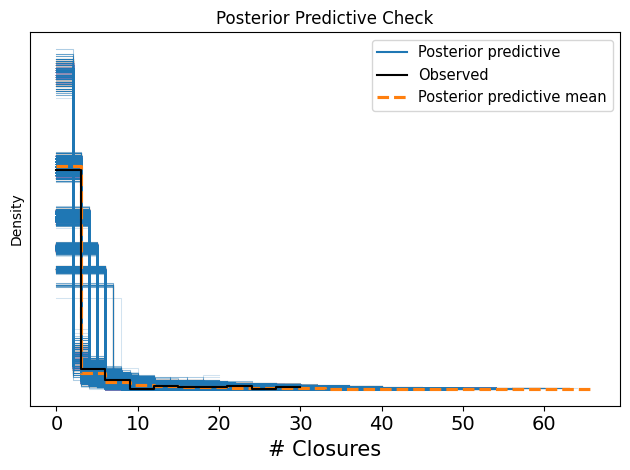

In [ ]:
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=['y'])
az.plot_ppc(ppc, observed_rug=True)
plt.title("Posterior Predictive Check")
plt.xlabel("# Closures")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

/Users/sepehrakbari/Projects/enrollment-cliff/.venv/lib/python3.10/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (169) in plot_posterior, generating only 40 plots
  warnings.warn(


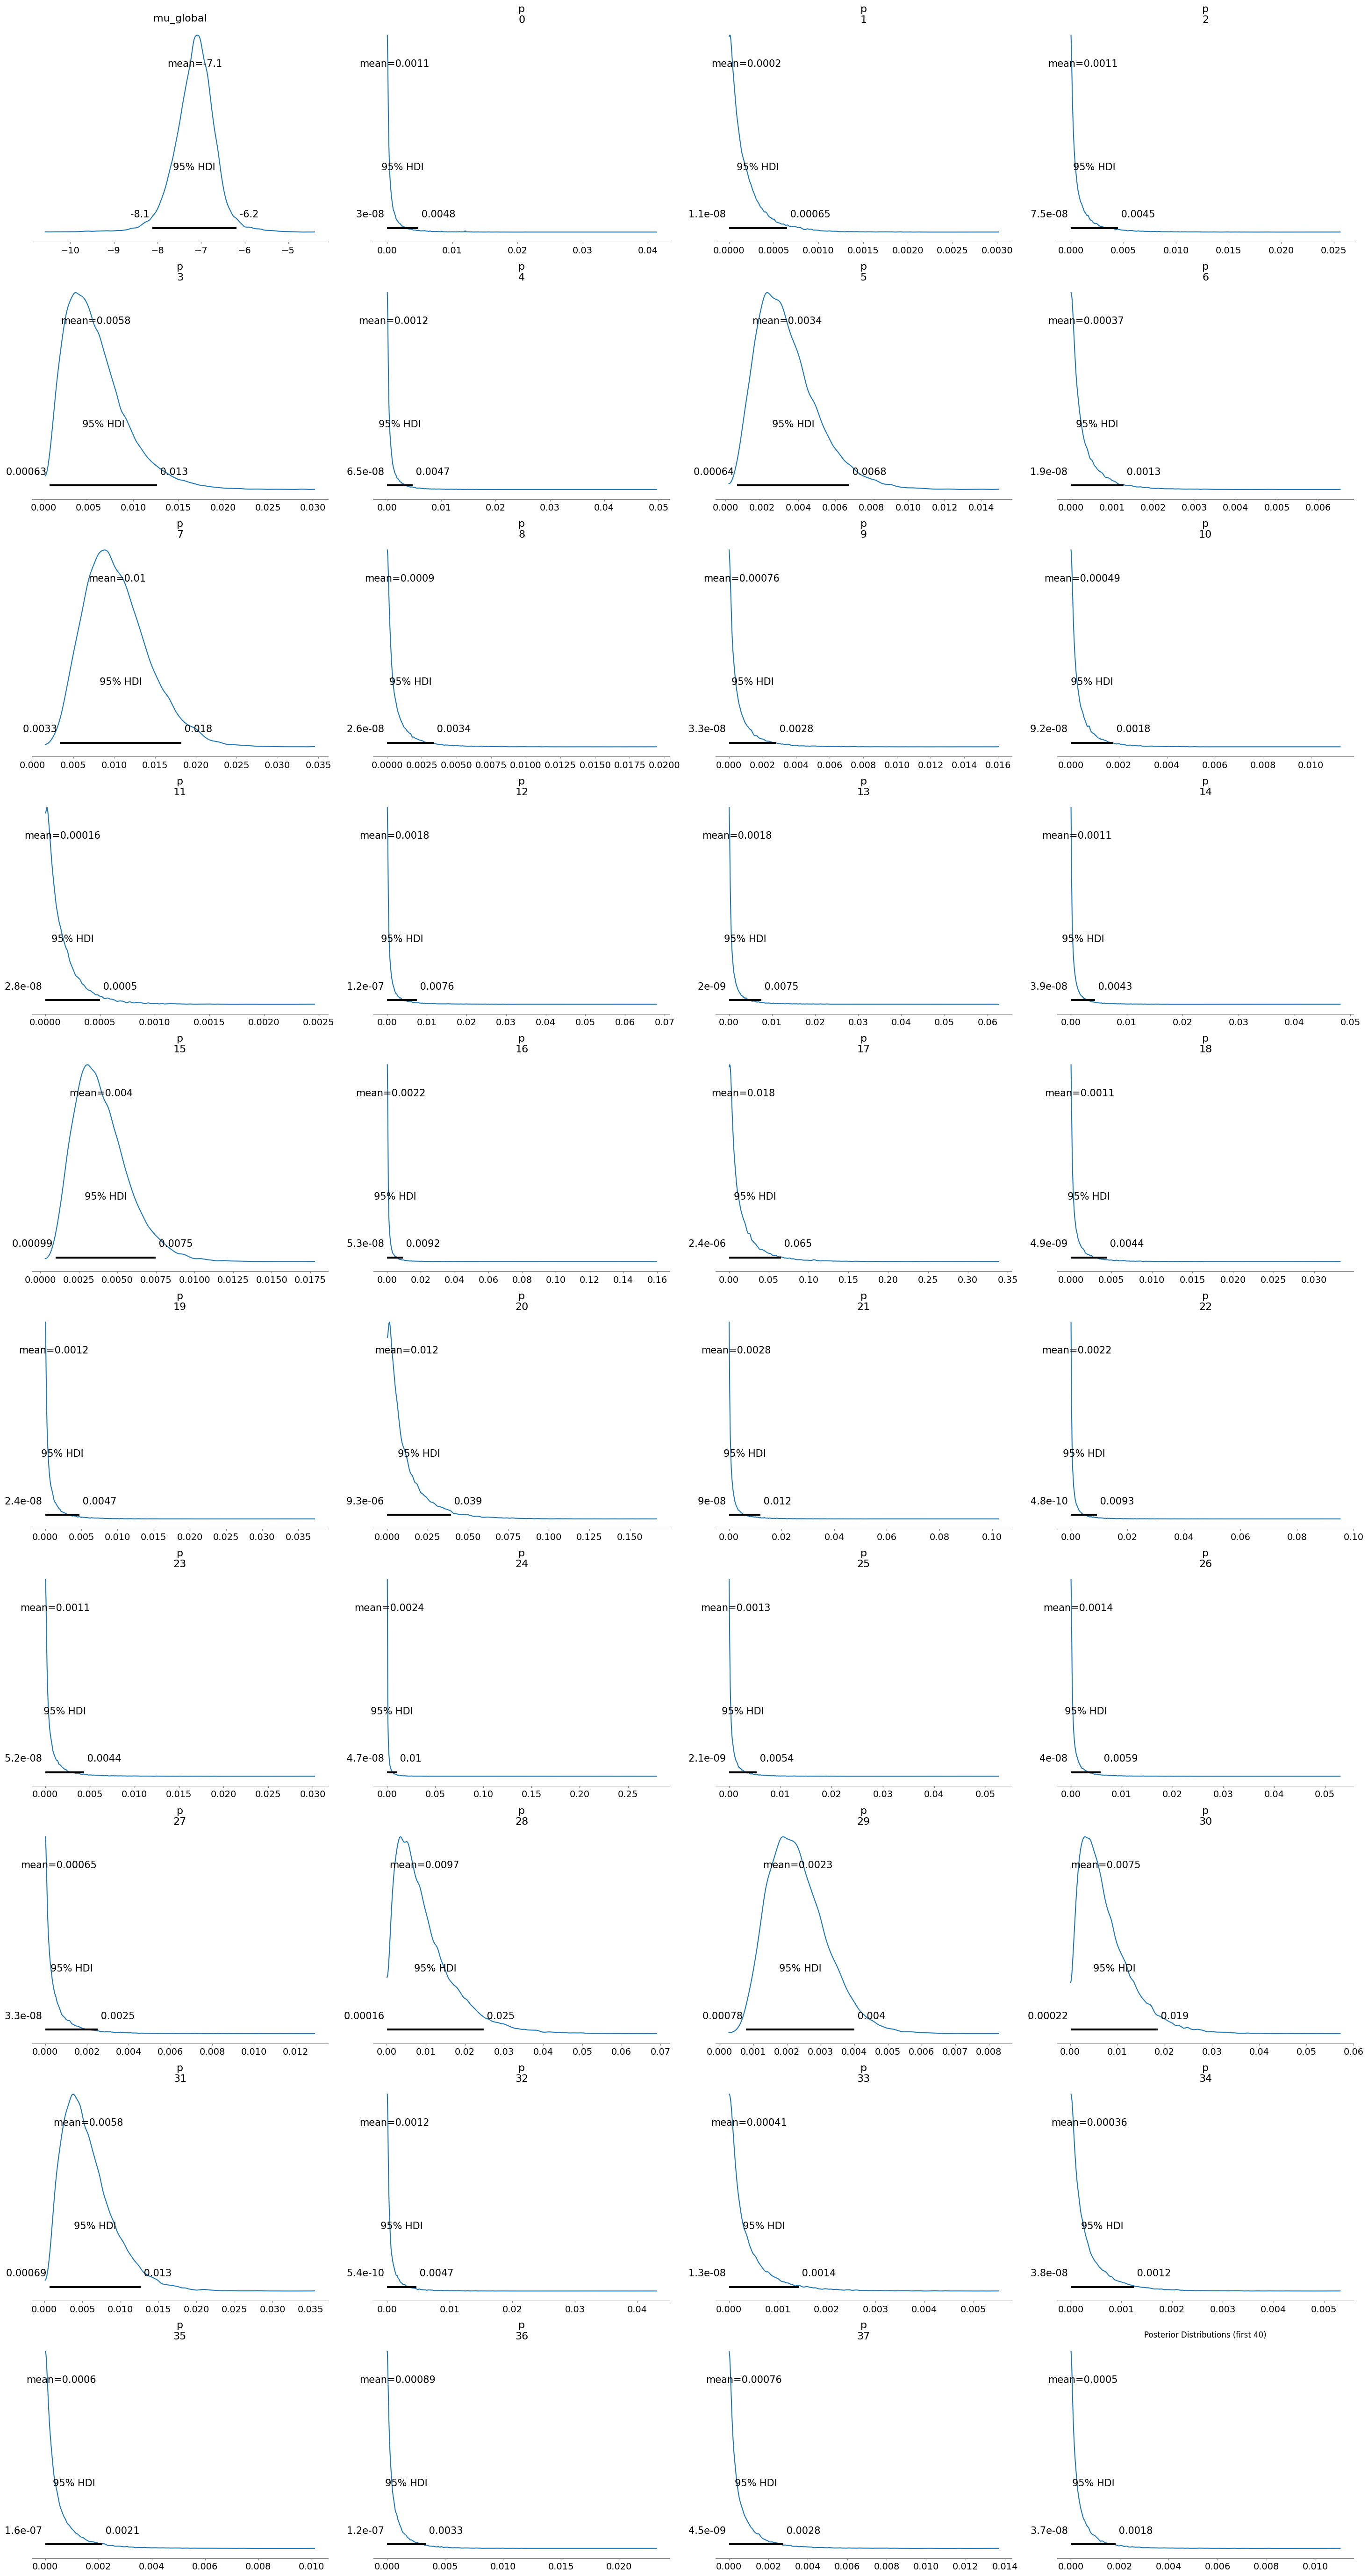

In [35]:
az.plot_posterior(trace, var_names=['mu_global', 'p'], hdi_prob=0.95)
plt.title("Posterior Distributions (first 40)")
plt.tight_layout()
plt.show()